# XGBoost Nang Cao — Feature Engineering + Log Target + Optuna
Muc tieu MAE: 500,000 - 700,000 VND

## 1. Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, pickle, os
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
os.makedirs('output', exist_ok=True)
print('Import xong!')

Import xong!


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Doc du lieu

In [2]:
df = pd.read_csv(r'output/Iphone_Database_filtered_train.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1070, 10)


,Dòng máy,Giá,Phiên bản,Tình trạng,Tinh_trang_tong_hop,Xuất xứ,Dung lượng (GB),Tình trạng pin,Pin_bucket,Chính sách bảo hành
0,iPhone 14 Pro Max,12500000,Quốc tế (Không khoá mạng),Đã sử dụng (chưa sửa chữa),Zin trầy xước,VN/A,128,84%,80-84%,Hết bảo hành
1,iPhone 16 Pro Max,25700000,Quốc tế (Không khoá mạng),Đã sử dụng (chưa sửa chữa),Zin không trầy xước,VN/A,256,99%,97-99%,Hết bảo hành
2,iPhone 8 plus,800000,Quốc tế (Không khoá mạng),Đã sửa chữa / thay linh kiện,"Màn thay, Pin thay",VN/A,64,100%,100%,Hết bảo hành


## 3. Feature Engineering

In [3]:
col_rename = {
    'Dong may':'Dong may', 'Dong may':'Dong may',
    'Dòng máy':'Dong may','Phiên bản':'Phien ban',
    'Tình trạng':'Tinh trang','Xuất xứ':'Xuat xu',
    'Dung lượng (GB)':'Dung luong (GB)',
    'Tình trạng pin':'Tinh trang pin',
    'Pin_bucket':'Pin_bucket',
    'Chính sách bảo hành':'Chinh sach bao hanh',
    'Giá':'Gia','Tinh_trang_tong_hop':'Tinh_trang_tong_hop'
}
df_eng = df.rename(columns=col_rename)

def feature_engineering(df):
    df = df.copy()
    gen_map = {
        'iphone se':5,'iphone 7':7,'iphone 7 plus':7,
        'iphone 8':8,'iphone 8 plus':8,
        'iphone x':10,'iphone xs':10,'iphone xs max':10,'iphone xr':10,
        'iphone 11':11,'iphone 11 pro':11,'iphone 11 pro max':11,
        'iphone 12':12,'iphone 12 mini':12,'iphone 12 pro':12,'iphone 12 pro max':12,
        'iphone 13':13,'iphone 13 mini':13,'iphone 13 pro':13,'iphone 13 pro max':13,
        'iphone 14':14,'iphone 14 plus':14,'iphone 14 pro':14,'iphone 14 pro max':14,
        'iphone 15':15,'iphone 15 plus':15,'iphone 15 pro':15,'iphone 15 pro max':15,
        'iphone 16':16,'iphone 16 plus':16,'iphone 16 pro':16,
        'iphone 16 pro max':16,'iphone 16e':16,'iphone air':16,
        'iphone 17':17,'iphone 17 pro':17,'iphone 17 pro max':17,'iphone 17e':17,
    }
    dl = df['Dong may'].str.lower().str.strip()
    df['Gen']         = dl.map(gen_map).fillna(10).astype(int)
    df['Is_Pro']      = dl.str.contains('pro').astype(int)
    df['Is_ProMax']   = dl.str.contains('pro max').astype(int)
    df['Is_Plus']     = dl.str.contains('plus').astype(int)
    df['Is_Mini']     = dl.str.contains('mini').astype(int)
    df['Is_Air']      = dl.str.contains('air').astype(int)
    pin_map = {'Duoi 80%':0,'80-84%':1,'85-89%':2,'90-94%':3,'95-96%':4,'97-99%':5,'100%':6}
    df['Pin_score']   = df['Pin_bucket'].str.strip().map(pin_map).fillna(3).astype(int)
    bh_map  = {'Het bao hanh':0,'Con bao hanh':1,'3 thang':1,'4-6 thang':2,'7-12 thang':3,'>12 thang':4}
    df['BH_score']    = df['Chinh sach bao hanh'].str.strip().map(bh_map).fillna(0).astype(int)
    tt_map  = {'Da sua chua / thay linh kien':0,'Da su dung (chua sua chua)':1,'Moi':2}
    df['TT_score']    = df['Tinh trang'].str.strip().map(tt_map).fillna(1).astype(int)
    tth = df['Tinh_trang_tong_hop'].str.lower().fillna('')
    df['Is_Zin']        = tth.str.contains('zin').astype(int)
    df['Is_No_Scratch'] = tth.str.contains('khong tray').astype(int)
    df['Has_ManThay']   = tth.str.contains('man thay|main thay').astype(int)
    df['Has_PinThay']   = tth.str.contains('pin thay').astype(int)
    df['Is_QuocTe']     = df['Phien ban'].str.contains('Quoc te', na=False).astype(int)
    df['Gen_sq']        = df['Gen'] ** 2
    df['Storage_x_Gen'] = df['Dung luong (GB)'] * df['Gen']
    return df

df_feat = feature_engineering(df_eng)
print(f'Feature engineering xong: {df_feat.shape[1]} cot')

Feature engineering xong: 26 cot


## 4. Chon features & Log-transform target

In [4]:
drop_cols = ['Gia','Tinh trang pin','Tinh_trang_tong_hop',
             'Pin_bucket','Chinh sach bao hanh','Tinh trang','Phien ban']
X = df_feat.drop(columns=drop_cols, errors='ignore')
y = df_feat['Gia']

numeric_features = [
    'Dung luong (GB)','Gen','Gen_sq','Storage_x_Gen',
    'Is_Pro','Is_ProMax','Is_Plus','Is_Mini','Is_Air',
    'Pin_score','BH_score','TT_score',
    'Is_Zin','Is_No_Scratch','Has_ManThay','Has_PinThay','Is_QuocTe',
]
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f'Features so ({len(numeric_features)}): {numeric_features}')
print(f'Features cat ({len(categorical_features)}): {categorical_features}')

# Log-transform target
y_log = np.log1p(y)

X_train, X_test, y_log_train, y_log_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
_, _, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print('Target: log1p(Gia) => inverse = expm1(pred)')

Features so (17): ['Dung luong (GB)', 'Gen', 'Gen_sq', 'Storage_x_Gen', 'Is_Pro', 'Is_ProMax', 'Is_Plus', 'Is_Mini', 'Is_Air', 'Pin_score', 'BH_score', 'TT_score', 'Is_Zin', 'Is_No_Scratch', 'Has_ManThay', 'Has_PinThay', 'Is_QuocTe']
Features cat (2): ['Dong may', 'Xuat xu']
Train: 856 | Test: 214
Target: log1p(Gia) => inverse = expm1(pred)


## 5. Pipeline & Baseline

In [5]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('num', 'passthrough', numeric_features),
])

def make_pipeline(params):
    return Pipeline([
        ('pre', preprocessor),
        ('model', XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, **params))
    ])

def eval_metrics(pipe, X_t, y_t_orig):
    pred = np.expm1(pipe.predict(X_t))
    return {
        'mae' : mean_absolute_error(y_t_orig, pred),
        'rmse': mean_squared_error(y_t_orig, pred)**0.5,
        'r2'  : r2_score(y_t_orig, pred),
        'mape': np.mean(np.abs((y_t_orig - pred)/y_t_orig))*100
    }

BASELINE_PARAMS = dict(
    n_estimators=800, max_depth=3, learning_rate=0.066,
    subsample=0.999, colsample_bytree=0.845, colsample_bylevel=0.502,
    min_child_weight=3, gamma=0.379, reg_alpha=0.00442, reg_lambda=0.021,
)
print('Training baseline...')
bp = make_pipeline(BASELINE_PARAMS)
bp.fit(X_train, y_log_train)
bm = eval_metrics(bp, X_test, y_test_orig)
print(f'Baseline -> MAE: {bm["mae"]:,.0f} VND | RMSE: {bm["rmse"]:,.0f} | R2: {bm["r2"]:.4f} | MAPE: {bm["mape"]:.2f}%')

Training baseline...
Baseline -> MAE: 1,440,158 VND | RMSE: 2,044,836 | R2: 0.9314 | MAPE: 17.70%


## 6. Optuna Tuning (150 trials)

In [6]:
CV = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1500, step=100),
        max_depth         = trial.suggest_int('max_depth', 3, 8),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        colsample_bynode  = trial.suggest_float('colsample_bynode', 0.5, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 15),
        gamma             = trial.suggest_float('gamma', 0.0, 2.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        max_delta_step    = trial.suggest_int('max_delta_step', 0, 5),
    )
    pipe   = make_pipeline(params)
    scores = cross_val_score(pipe, X_train, y_log_train, cv=CV,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores.mean()

N_TRIALS = 150
print(f'Optuna: {N_TRIALS} trials...')
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=20),
    pruner=optuna.pruners.HyperbandPruner(),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f'Best log-MAE (CV): {study.best_value:.6f}')
print('\nBest params:')
for k,v in best_params.items():
    print(f'  {k}: {v}')

Optuna: 150 trials...


Best trial: 74. Best value: 0.138538: 100%|██████████| 150/150 [00:46<00:00,  3.21it/s]

Best log-MAE (CV): 0.138538

Best params:
  n_estimators: 900
  max_depth: 4
  learning_rate: 0.011053932071251472
  subsample: 0.6306678145204497
  colsample_bytree: 0.9767968003130095
  colsample_bylevel: 0.5622582938910496
  colsample_bynode: 0.5144521748735422
  min_child_weight: 3
  gamma: 0.006230339613541663
  reg_alpha: 2.443980888863365e-05
  reg_lambda: 0.00010812540241074135
  max_delta_step: 3


## 7. Train & Danh gia model tot nhat

In [7]:
print('Training best model...')
best_pipe = make_pipeline(best_params)
best_pipe.fit(X_train, y_log_train)
bst = eval_metrics(best_pipe, X_test, y_test_orig)

TARGET_LO, TARGET_HI = 500_000, 700_000
print('\n' + '='*60)
print(f'{"":25s} {"Baseline":>15s} {"Best Optuna":>15s}')
print('='*60)
print(f'{"MAE (VND)":25s} {bm["mae"]:>15,.0f} {bst["mae"]:>15,.0f}')
print(f'{"RMSE (VND)":25s} {bm["rmse"]:>15,.0f} {bst["rmse"]:>15,.0f}')
print(f'{"R2":25s} {bm["r2"]:>15.4f} {bst["r2"]:>15.4f}')
print(f'{"MAPE (%)":25s} {bm["mape"]:>15.2f} {bst["mape"]:>15.2f}')
improv = (bm['mae'] - bst['mae']) / bm['mae'] * 100
print('='*60)
print(f'Cai thien MAE: {improv:+.2f}%')
if TARGET_LO <= bst['mae'] <= TARGET_HI:
    print(f'*** DAT MUC TIEU {TARGET_LO:,} - {TARGET_HI:,} VND ***')
elif bst['mae'] < TARGET_LO:
    print(f'*** VUOT MUC TIEU! MAE = {bst["mae"]:,.0f} VND ***')
else:
    print(f'Can giam them {bst["mae"]-TARGET_HI:,.0f} VND nua.')

Training best model...

                                 Baseline     Best Optuna
MAE (VND)                       1,440,158       1,239,680
RMSE (VND)                      2,044,836       1,929,620
R2                                 0.9314          0.9389
MAPE (%)                            17.70           15.59
Cai thien MAE: +13.92%
Can giam them 539,680 VND nua.


## 8. Bieu do ket qua

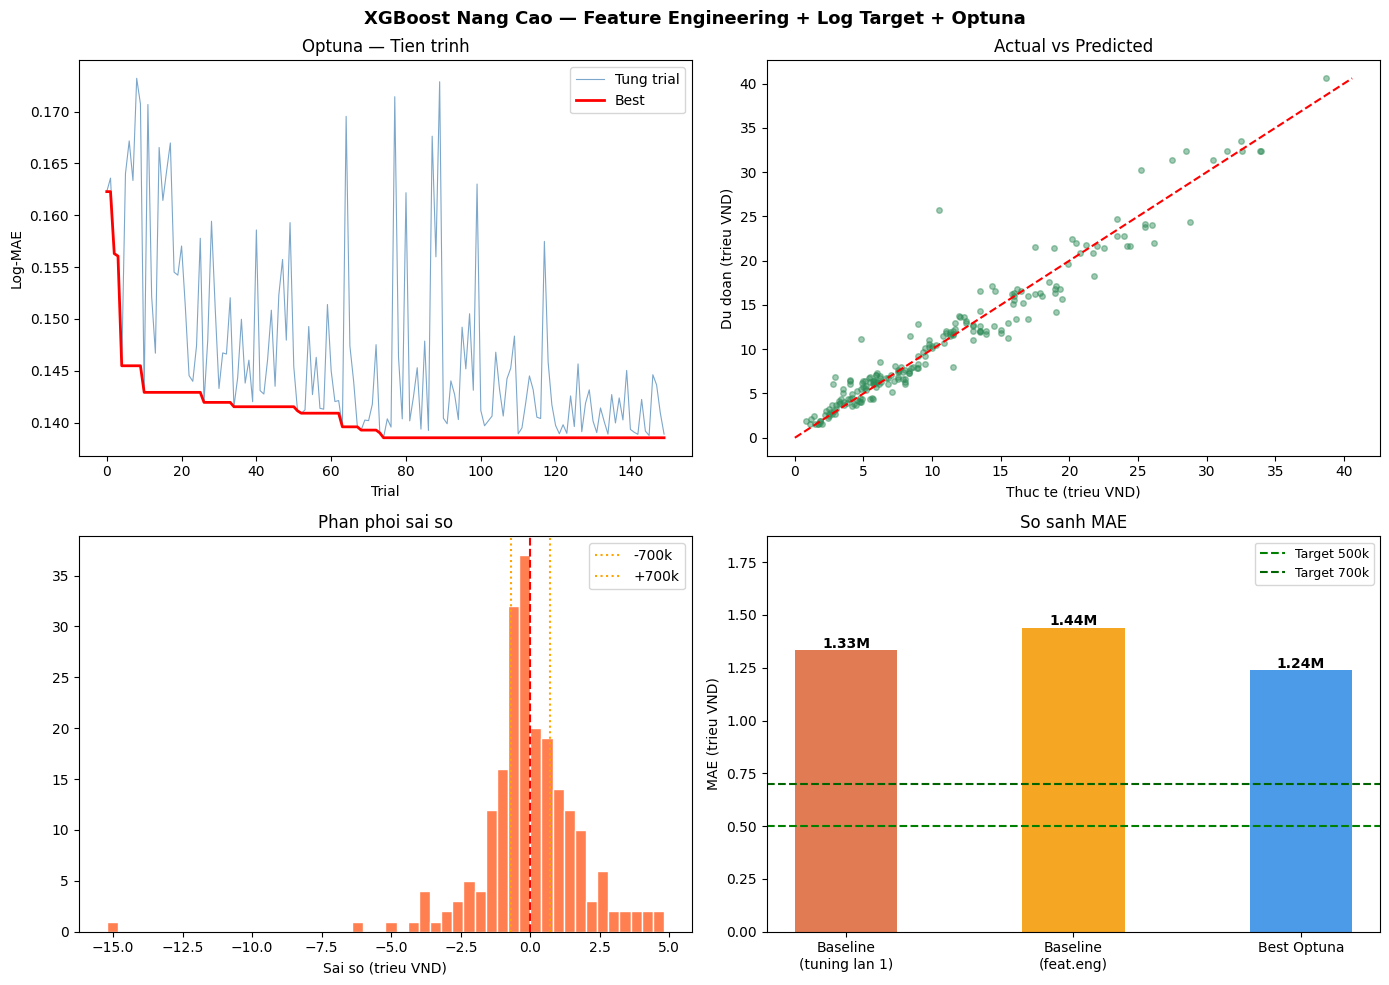

Bieu do luu: output/xgboost_advanced_result.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('XGBoost Nang Cao — Feature Engineering + Log Target + Optuna',
             fontsize=13, fontweight='bold')

# Optuna history
ax = axes[0,0]
vals = [t.value for t in study.trials if t.value is not None]
ax.plot(vals, color='steelblue', linewidth=0.8, alpha=0.7, label='Tung trial')
ax.plot(pd.Series(vals).cummin(), color='red', linewidth=2, label='Best')
ax.set_title('Optuna — Tien trinh'); ax.set_xlabel('Trial'); ax.set_ylabel('Log-MAE')
ax.legend()

# Actual vs Predicted
ax = axes[0,1]
pred_test = np.expm1(best_pipe.predict(X_test))
lim = max(y_test_orig.max(), pred_test.max()) / 1e6
ax.scatter(y_test_orig/1e6, pred_test/1e6, alpha=0.45, s=16, color='seagreen')
ax.plot([0,lim],[0,lim],'r--')
ax.set_title('Actual vs Predicted'); ax.set_xlabel('Thuc te (trieu VND)'); ax.set_ylabel('Du doan (trieu VND)')

# Residual
ax = axes[1,0]
residuals = (y_test_orig.values - pred_test) / 1e6
ax.hist(residuals, bins=50, color='coral', edgecolor='white')
ax.axvline(0, color='red', linestyle='--')
ax.axvline(-0.7, color='orange', linestyle=':', label='-700k')
ax.axvline(0.7,  color='orange', linestyle=':', label='+700k')
ax.set_title('Phan phoi sai so'); ax.set_xlabel('Sai so (trieu VND)'); ax.legend()

# MAE comparison
ax = axes[1,1]
labels = ['Baseline\n(tuning lan 1)', 'Baseline\n(feat.eng)', 'Best Optuna']
values = [1_333_692, bm['mae'], bst['mae']]
bars = ax.bar(labels, [v/1e6 for v in values], color=['#e07b54','#f5a623','#4c9be8'], width=0.45)
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{v/1e6:.2f}M', ha='center', fontsize=10, fontweight='bold')
ax.axhline(TARGET_LO/1e6, color='green', linestyle='--', label='Target 500k')
ax.axhline(TARGET_HI/1e6, color='darkgreen', linestyle='--', label='Target 700k')
ax.set_title('So sanh MAE'); ax.set_ylabel('MAE (trieu VND)')
ax.set_ylim(0, max(values)/1e6*1.3); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('output/xgboost_advanced_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bieu do luu: output/xgboost_advanced_result.png')

## 9. Feature Importance

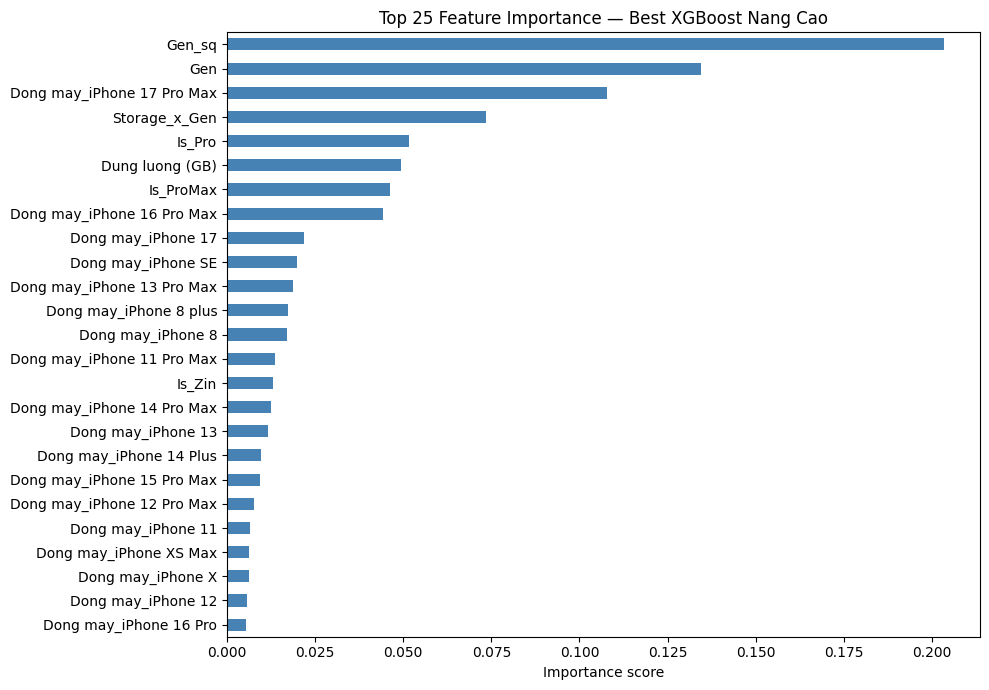

In [9]:
ohe_names = best_pipe.named_steps['pre'].named_transformers_['cat']\
            .get_feature_names_out(categorical_features).tolist()
all_names   = ohe_names + numeric_features
feat_imp    = pd.Series(best_pipe.named_steps['model'].feature_importances_,
                        index=all_names).sort_values(ascending=False).head(25)

fig2, ax2 = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax2, color='steelblue')
ax2.invert_yaxis()
ax2.set_title('Top 25 Feature Importance — Best XGBoost Nang Cao', fontsize=12)
ax2.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('output/feature_importance_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Luu model & tham so tot nhat

In [10]:
save_info = {'pipeline': best_pipe, 'best_params': best_params, 'metrics': bst}
with open('output/xgboost_advanced_model.pkl', 'wb') as f:
    pickle.dump(save_info, f)
print('Model luu tai: output/xgboost_advanced_model.pkl')

print('\nTham so tot nhat:')
print('xgb_model = XGBRegressor(')
for k,v in best_params.items():
    print(f'    {k}={round(v,8) if isinstance(v,float) else v},')
print("    objective='reg:squarederror', random_state=42, n_jobs=-1")
print(')')
print('# Nho dung log1p(y) khi train va expm1(pred) khi predict!')

Model luu tai: output/xgboost_advanced_model.pkl

Tham so tot nhat:
xgb_model = XGBRegressor(
    n_estimators=900,
    max_depth=4,
    learning_rate=0.01105393,
    subsample=0.63066781,
    colsample_bytree=0.9767968,
    colsample_bylevel=0.56225829,
    colsample_bynode=0.51445217,
    min_child_weight=3,
    gamma=0.00623034,
    reg_alpha=2.444e-05,
    reg_lambda=0.00010813,
    max_delta_step=3,
    objective='reg:squarederror', random_state=42, n_jobs=-1
)
# Nho dung log1p(y) khi train va expm1(pred) khi predict!


## 11. Du doan mau moi

In [11]:
# Ham chuan bi input mau moi
def predict_price(dong_may, dung_luong_gb, pin_bucket,
                 tinh_trang='Da su dung (chua sua chua)',
                 tinh_trang_tong_hop='Zin khong tray xuoc',
                 xuat_xu='VN/A', bao_hanh='Het bao hanh',
                 phien_ban='Quoc te (Khong khoa mang)'):
    row = pd.DataFrame([{
        'Dong may': dong_may, 'Phien ban': phien_ban,
        'Tinh trang': tinh_trang, 'Tinh_trang_tong_hop': tinh_trang_tong_hop,
        'Xuat xu': xuat_xu, 'Dung luong (GB)': dung_luong_gb,
        'Tinh trang pin': '95%', 'Pin_bucket': pin_bucket,
        'Chinh sach bao hanh': bao_hanh,
    }])
    row_feat = feature_engineering(row)
    drop_c   = ['Tinh trang pin','Tinh_trang_tong_hop','Pin_bucket',
                'Chinh sach bao hanh','Tinh trang','Phien ban']
    row_feat = row_feat.drop(columns=drop_c, errors='ignore')
    pred_log = best_pipe.predict(row_feat)[0]
    return np.expm1(pred_log)

# Thi thu
samples = [
    ('iPhone 14 Pro Max', 256, '97-99%'),
    ('iPhone 11', 64, '90-94%'),
    ('iPhone 15 Pro Max', 256, '97-99%'),
    ('iPhone 13', 128, '100%'),
]
print(f'{"Model":<25} {"Storage":>8} {"Pin":<10} {"Du doan":>15}')
print('-'*65)
for dong, gb, pin in samples:
    p = predict_price(dong, gb, pin)
    print(f'{dong:<25} {gb:>5}GB {pin:<10} {p:>13,.0f} VND')

Model                      Storage Pin                Du doan
-----------------------------------------------------------------
iPhone 14 Pro Max           256GB 97-99%        12,338,271 VND
iPhone 11                    64GB 90-94%         3,588,802 VND
iPhone 15 Pro Max           256GB 97-99%        16,402,519 VND
iPhone 13                   128GB 100%           6,892,667 VND
